# OT in linear ICA

## Experiment 1: The "Full Hybrid" Stress Test
### Benchmarking Robustness Against Statistical Heterogeneity

While isolating specific failure modes is scientifically useful, real-world data is rarely statistically uniform. This experiment introduces a **Full Hybrid** environment to test the limits of algorithmic robustness in high-dimensional spaces (30-40 dimensions).

#### The Challenge: A Statistical Cocktail
We challenge the algorithms to simultaneously unmix a chaotic mixture of 8 distinct statistical "flavors":
* **Super-Gaussian (Heavy Tails):** Laplace, Student-t
* **Sub-Gaussian (Bounded):** Uniform
* **Skewed / Strictly Positive:** Chi-square, Exponential
* **Discrete / Stepped:** Bernoulli, Poisson, Binomial

#### Why Hybrid Mixtures Break Traditional ICA
Parametric algorithms like **FastICA** rely on a specific contrast function (e.g., `logcosh`) to approximate non-Gaussianity. This assumes a somewhat uniform "type" of non-Gaussianity across all latent sources. In a hybrid mixture, the parametric approximations clash—FastICA’s Newton solver often becomes confused by the conflicting local curvatures of skewed vs. sub-Gaussian signals, leading to erratic convergence and high **Amari Error**.

#### The Geometric Solution (OT-ICA)
**OT-ICA** utilizes the Wasserstein-2 distance to measure the global geometric discrepancy between the data and a Gaussian target. Theoretically, this metric is agnostic to the "type" of non-Gaussianity (skewed, heavy-tailed, or discrete). This experiment benchmarks whether this geometric approach can maintain stability where local density approximations fail.

In [1]:
import numpy as np
import torch
import pandas as pd
import time
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from wasserstein_ica import WassersteinICA

In [ ]:
# ==========================================
# 1. Global Thesis Configuration & Helpers
# ==========================================
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    plt.rcParams.update({
        'figure.figsize': (12, 6),
        'figure.dpi': 300,
        'axes.prop_cycle': plt.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.frameon': True,
        'legend.fontsize': 11,
        'lines.linewidth': 2.5
    })

set_thesis_theme()

In [ ]:
def amari_error(W, A):
    if W is None or np.any(np.isnan(W)): return np.nan
    P = np.abs(np.dot(W, A))
    n = P.shape[0]
    row_sum = np.sum(P / np.max(P, axis=1, keepdims=True), axis=1) - 1.0
    col_sum = np.sum(P / np.max(P, axis=0, keepdims=True), axis=0) - 1.0
    return (np.sum(row_sum) + np.sum(col_sum)) / (2 * n)

In [3]:
# ==========================================
# 2. Unified Data Generators
# ==========================================
def generate_mixture(n_dim, n_samples, config_type, param=None, seed=None):
    if seed is not None: np.random.seed(seed)
    
    # Standard Generators
    def gen_laplace(): return np.random.laplace(0, 1/np.sqrt(2), size=n_samples)
    def gen_bernoulli(): return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): s = np.random.standard_t(df=3, size=n_samples); return s / np.std(s)
    
    # Parameterized Discrete Generators
    def gen_poisson(lam=3.0): s = np.random.poisson(lam=lam, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_binomial(n=10, p=0.5): s = np.random.binomial(n=n, p=p, size=n_samples); return (s - np.mean(s)) / np.std(s)
    
    # Positive continuous
    def gen_chisquare(): s = np.random.chisquare(df=2, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_exponential(): s = np.random.exponential(scale=1.0, size=n_samples); return (s - np.mean(s)) / np.std(s)

    pools = {
        'Full Hybrid': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
        'Continuous Only': [gen_laplace, gen_uniform, gen_student_t, gen_chisquare, gen_exponential],
        'Discrete Only': [gen_bernoulli, gen_poisson, gen_binomial],
        'Strictly Super-Gaussian': [gen_laplace, gen_student_t, gen_chisquare, gen_exponential],
        'Zero Gaussian': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
    }
    
    sources = []
    
    # Mode A: Ablation Pools
    if config_type in pools:
        active_pool = pools[config_type]
        if config_type != 'Zero Gaussian':
            sources.append(np.random.normal(0, 1, size=n_samples)) # Add Gaussian
            n_to_gen = n_dim - 1
        else:
            n_to_gen = n_dim
        for _ in range(n_to_gen): sources.append(np.random.choice(active_pool)())
            
    # Mode B: Single Isolated Discrete Type
    else:
        sources.append(np.random.normal(0, 1, size=n_samples)) # Baseline Gaussian
        for _ in range(n_dim - 1):
            if config_type == 'Bernoulli': sources.append(gen_bernoulli())
            elif config_type == 'Poisson': sources.append(gen_poisson(lam=param if param else 3.0))
            elif config_type == 'Binomial': sources.append(gen_binomial(n=param if param else 10))
            
    S = np.stack(sources)
    np.random.shuffle(S) # Hide the Gaussian
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
    return A @ S, A

In [4]:
# ==========================================
# 3. Unified Worker Function (UPDATED)
# ==========================================
def run_ica_trial(dim, trial, n_samples, config_type, method, param=None):
    torch.set_num_threads(1)
    X_np, A_true = generate_mixture(dim, n_samples, config_type, param, seed=trial)
    
    score = np.nan
    converged = False

    if method == 'FastICA':
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            try:
                # HIGH COMPUTE explicitly set to 10000 iterations
                fast_ica = FastICA(n_components=dim, max_iter=10000, tol=1e-4, random_state=trial)
                fast_ica.fit(X_np.T)
                score = amari_error(fast_ica.components_, A_true)
                if not any(isinstance(m.message, ConvergenceWarning) for m in w):
                    if not np.isnan(score) and score < 1.0: converged = True
            except Exception: pass

    elif method == 'OT-ICA':
        try:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
            ica = WassersteinICA(X_torch)
            ica.whiten()
            W_white = ica.W_white.cpu().numpy()
            
            extracted = []
            n_restarts = min(dim * 4, 150)
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts, dither_sigma=0.01)
                extracted.append(w)
                
            W_stiefel = ica.optimize_symmetric(n_components=dim, max_iter=400, lr=0.25, init_w=torch.stack(extracted), optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
            score = amari_error(W_stiefel.cpu().numpy() @ W_white, A_true)
            if not np.isnan(score) and score < 1.0: converged = True
        except Exception: pass

    # THE FIX IS HERE: Added 'Config_Param' to the dictionary output
    return {'Dim': dim, 'Config': config_type, 'Config_Param': param, 'Method': method, 'Error': score, 'Conv': int(converged)}

In [5]:
def plot_results(df, title, palette, x_col='Config'):
    # 1. Prepare Amari Error Data (Both Algorithms)
    df_plot = df.copy()
    # Apply a visual penalty for strictly failed/NaN runs so they appear on the chart
    df_plot['Error'] = df_plot['Error'].fillna(1.5) 

    # 2. Prepare Convergence Data (FastICA ONLY)
    df_conv = df[df['Method'] == 'FastICA'].groupby(['Dim', x_col, 'Method'])['Conv'].mean().reset_index()
    df_conv['Success Rate (%)'] = df_conv['Conv'] * 100

    # --- Font Size Controls ---
    TITLE_FS = 20   # Title font size
    LABEL_FS = 18   # X/Y Axis label font size
    TICK_FS = 16    # X/Y Tick numbers/labels font size
    LEGEND_FS = 16  # Legend text and title font size
    # --------------------------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # --- Subplot 1: Amari Error (Both) ---
    sns.barplot(data=df_plot, x=x_col, y='Error', hue='Method', ax=ax1, palette=palette, edgecolor='black', errorbar='ci')
    
    # Apply title size
    ax1.set_title(f"Amari Error: {title}\n(Lower is Better)", fontsize=TITLE_FS)
    
    # Apply axis label sizes
    ax1.set_xlabel(x_col, fontsize=LABEL_FS)
    ax1.set_ylabel('Error', fontsize=LABEL_FS)
    
    # Apply tick label sizes
    ax1.tick_params(axis='y', labelsize=TICK_FS)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
    
    # Apply legend size
    ax1.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    
    ax1.set_ylim(0, 2.0) 

    # --- Subplot 2: Convergence Rate (FastICA Only) ---
    fast_palette = {'FastICA': palette['FastICA']}
    sns.barplot(data=df_conv, x=x_col, y='Success Rate (%)', hue='Method', ax=ax2, palette=fast_palette, edgecolor='black')
    
    # Apply title size
    ax2.set_title(f"Mechanical Convergence Rate: {title}\n(FastICA Only - Newton Solver Stability)", fontsize=TITLE_FS)
    
    # Apply axis label sizes
    ax2.set_xlabel(x_col, fontsize=LABEL_FS)
    ax2.set_ylabel('Success Rate (%)', fontsize=LABEL_FS)
    
    # Apply tick label sizes
    ax2.tick_params(axis='y', labelsize=TICK_FS)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
    
    # Apply legend size
    ax2.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    
    ax2.set_ylim(0, 105)

    plt.tight_layout()
    plt.show()
    
    # Display the numerical summary table
    display(df.groupby(['Method', x_col, 'Dim'])[['Error', 'Conv']].mean().round(4))

In [6]:
DIMENSIONS = [30, 40]
POOLS = ['Continuous Only', 'Discrete Only', 'Strictly Super-Gaussian', 'Zero Gaussian', 'Full Hybrid']
METHODS = ['FastICA', 'OT-ICA']
N_SAMPLES = 10000; N_TRIALS = 5 

print("--- Step 1: Sub-Pool Ablation Study ---")
tasks = [(dim, trial, N_SAMPLES, p, m, None) for dim in DIMENSIONS for p in POOLS for m in METHODS for trial in range(N_TRIALS)]
results_ablation = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks))

df_ablation = pd.DataFrame(results_ablation)

--- Step 1: Sub-Pool Ablation Study ---


  0%|          | 0/100 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/tmp/ipykernel_3352586/3090304677.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
/tmp/ipykernel_3352586/3090304677.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)


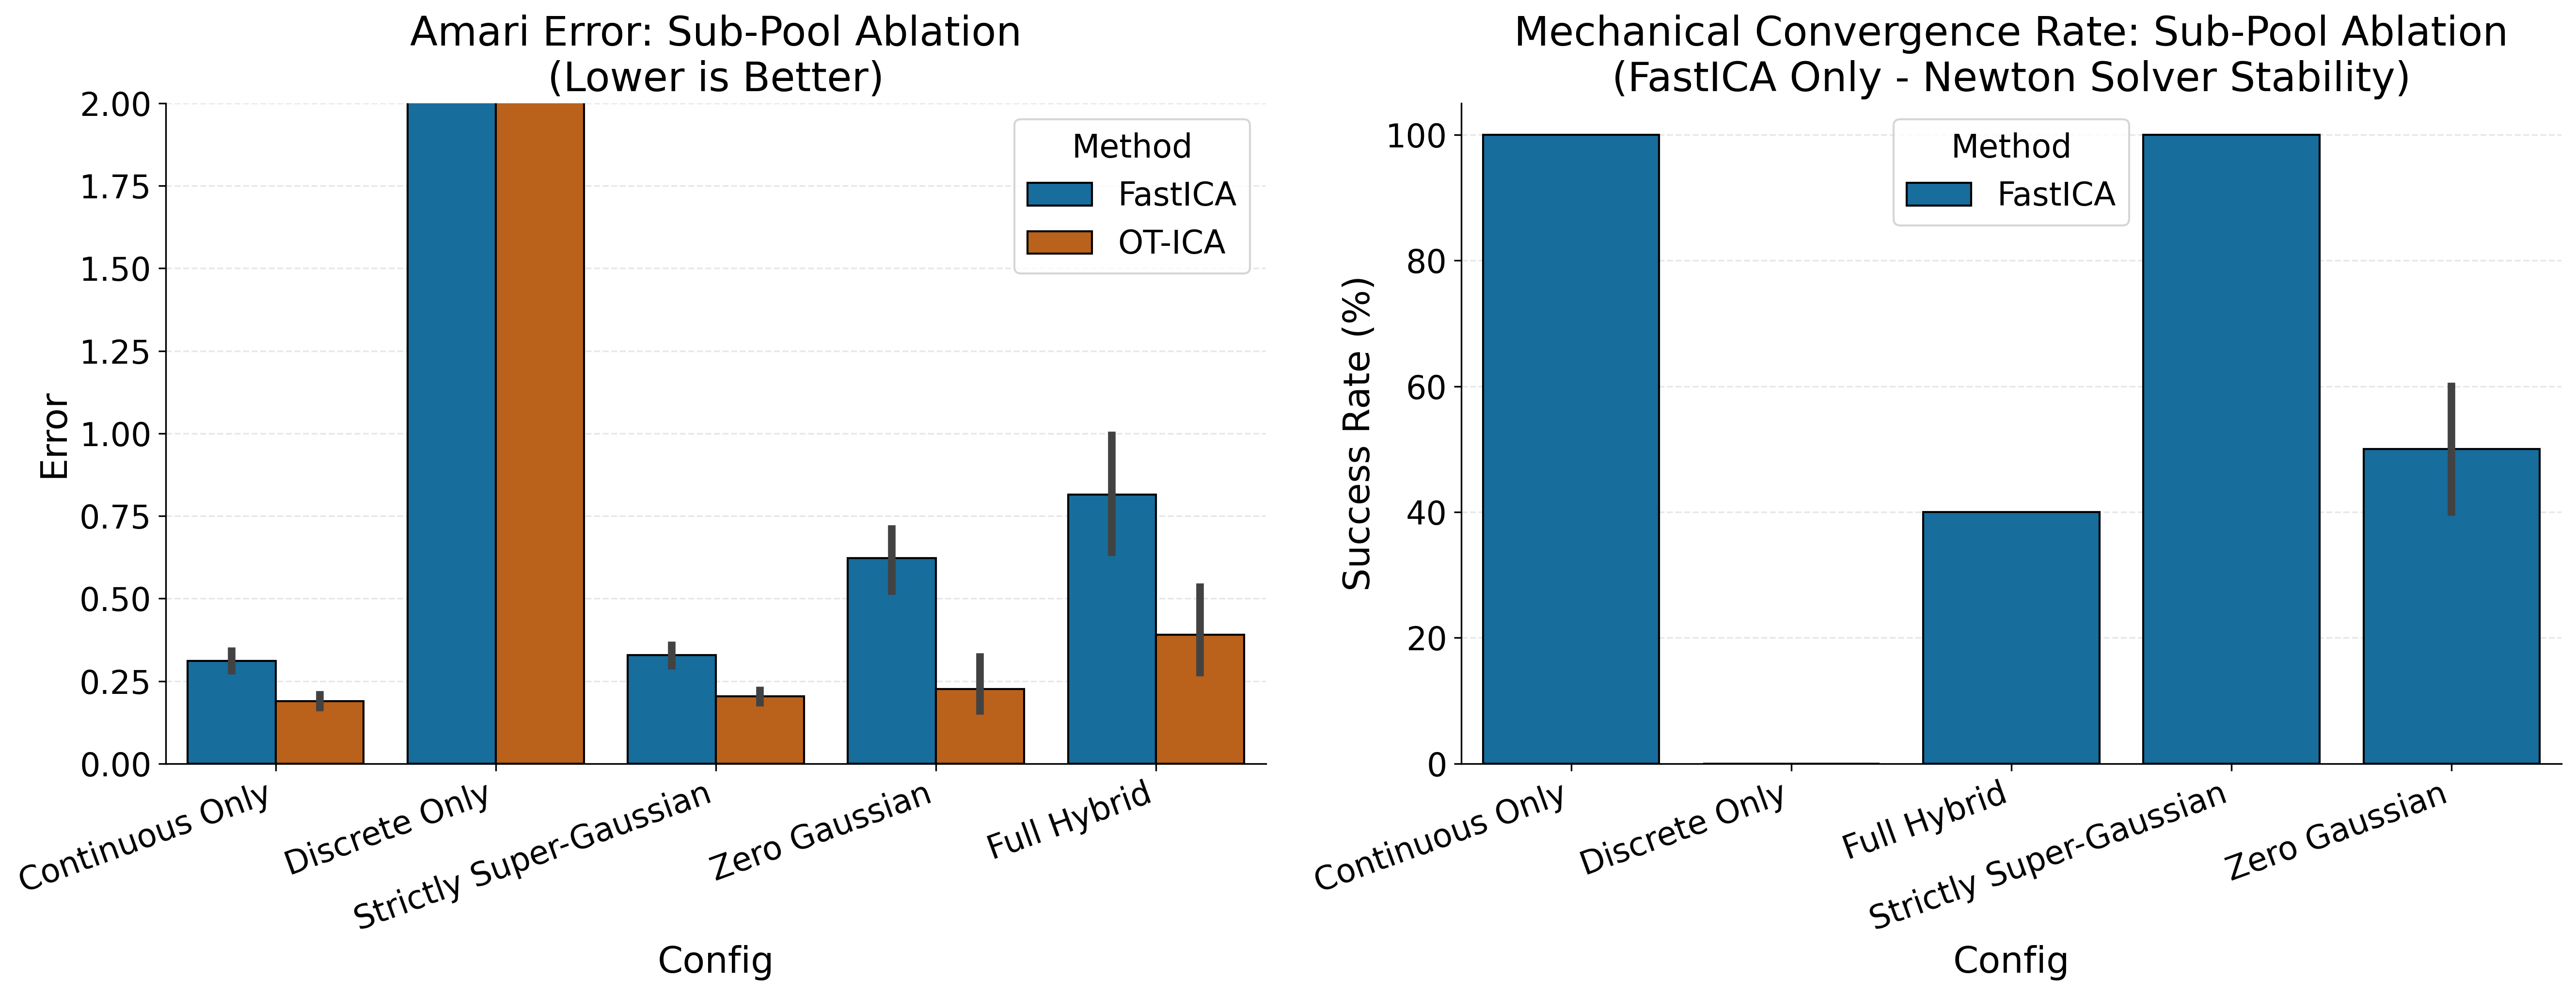

Error  Conv
Method  Config                  Dim              
FastICA Continuous Only         30   0.2672   1.0
                                40   0.3545   1.0
        Discrete Only           30   4.1976   0.0
                                40   5.8592   0.0
        Full Hybrid             30   0.7109   0.4
                                40   0.9199   0.4
        Strictly Super-Gaussian 30   0.2813   1.0
                                40   0.3764   1.0
        Zero Gaussian           30   0.5771   0.4
                                40   0.6688   0.6
OT-ICA  Continuous Only         30   0.1603   1.0
                                40   0.2184   1.0
        Discrete Only           30   3.8738   0.0
                                40   5.6736   0.0
        Full Hybrid             30   0.2545   1.0
                                40   0.5255   1.0
        Strictly Super-Gaussian 30   0.1746   1.0
                                40   0.2327   1.0
        Zero Gaussian           30   0.1448   1.0
                                40   0.3063   1.0

In [7]:
plot_results(df_ablation, "Sub-Pool Ablation", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})

# Experiment 2:Discrete Failures
### Jagged Landscapes vs. Insufficient Non-Gaussianity

Previous tests show that both FastICA and OT-ICA struggle with discrete distributions like Poisson and Binomial. This experiment isolates the two potential causes for these failures:

#### 1. The "Gaussian Blur" (Data Limitation)
By the Central Limit Theorem, distributions like Poisson (high $\lambda$) or Binomial (high $n$) rapidly approach a Gaussian shape. If the Wasserstein gap is too small, the signal is fundamentally inseparable, regardless of the algorithm used.

#### 2. Geometric Jaggedness (Optimization Limitation)
Discrete data lacks a smooth probability density. This creates a "stair-stepped" optimization landscape filled with sharp local minima. We investigate whether these "jagged traps" stall gradient-based solvers even when the signal is mathematically non-Gaussian.

#### Experiment Roadmap
* **Sub-Pool Ablation:** Comparing unmixing performance on purely continuous pools versus purely discrete pools.
* **Surface Bifurcation Analysis:** Mapping the raw objective landscapes of $W_2^2$ vs. Logcosh Proxy Negentropy to visualize "Harsh" (low $\lambda/n$) vs. "Standard" discrete signals.
* **Compute Regime Stress Test:** Determining if high-restart, high-iteration optimization can "power through" jagged landscapes when a valid non-Gaussian signal exists.

--- Step 2: Isolating Discrete Failure Modes ---


  0%|          | 0/60 [00:00<?, ?it/s]

/tmp/ipykernel_3352586/3090304677.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
/tmp/ipykernel_3352586/3090304677.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)


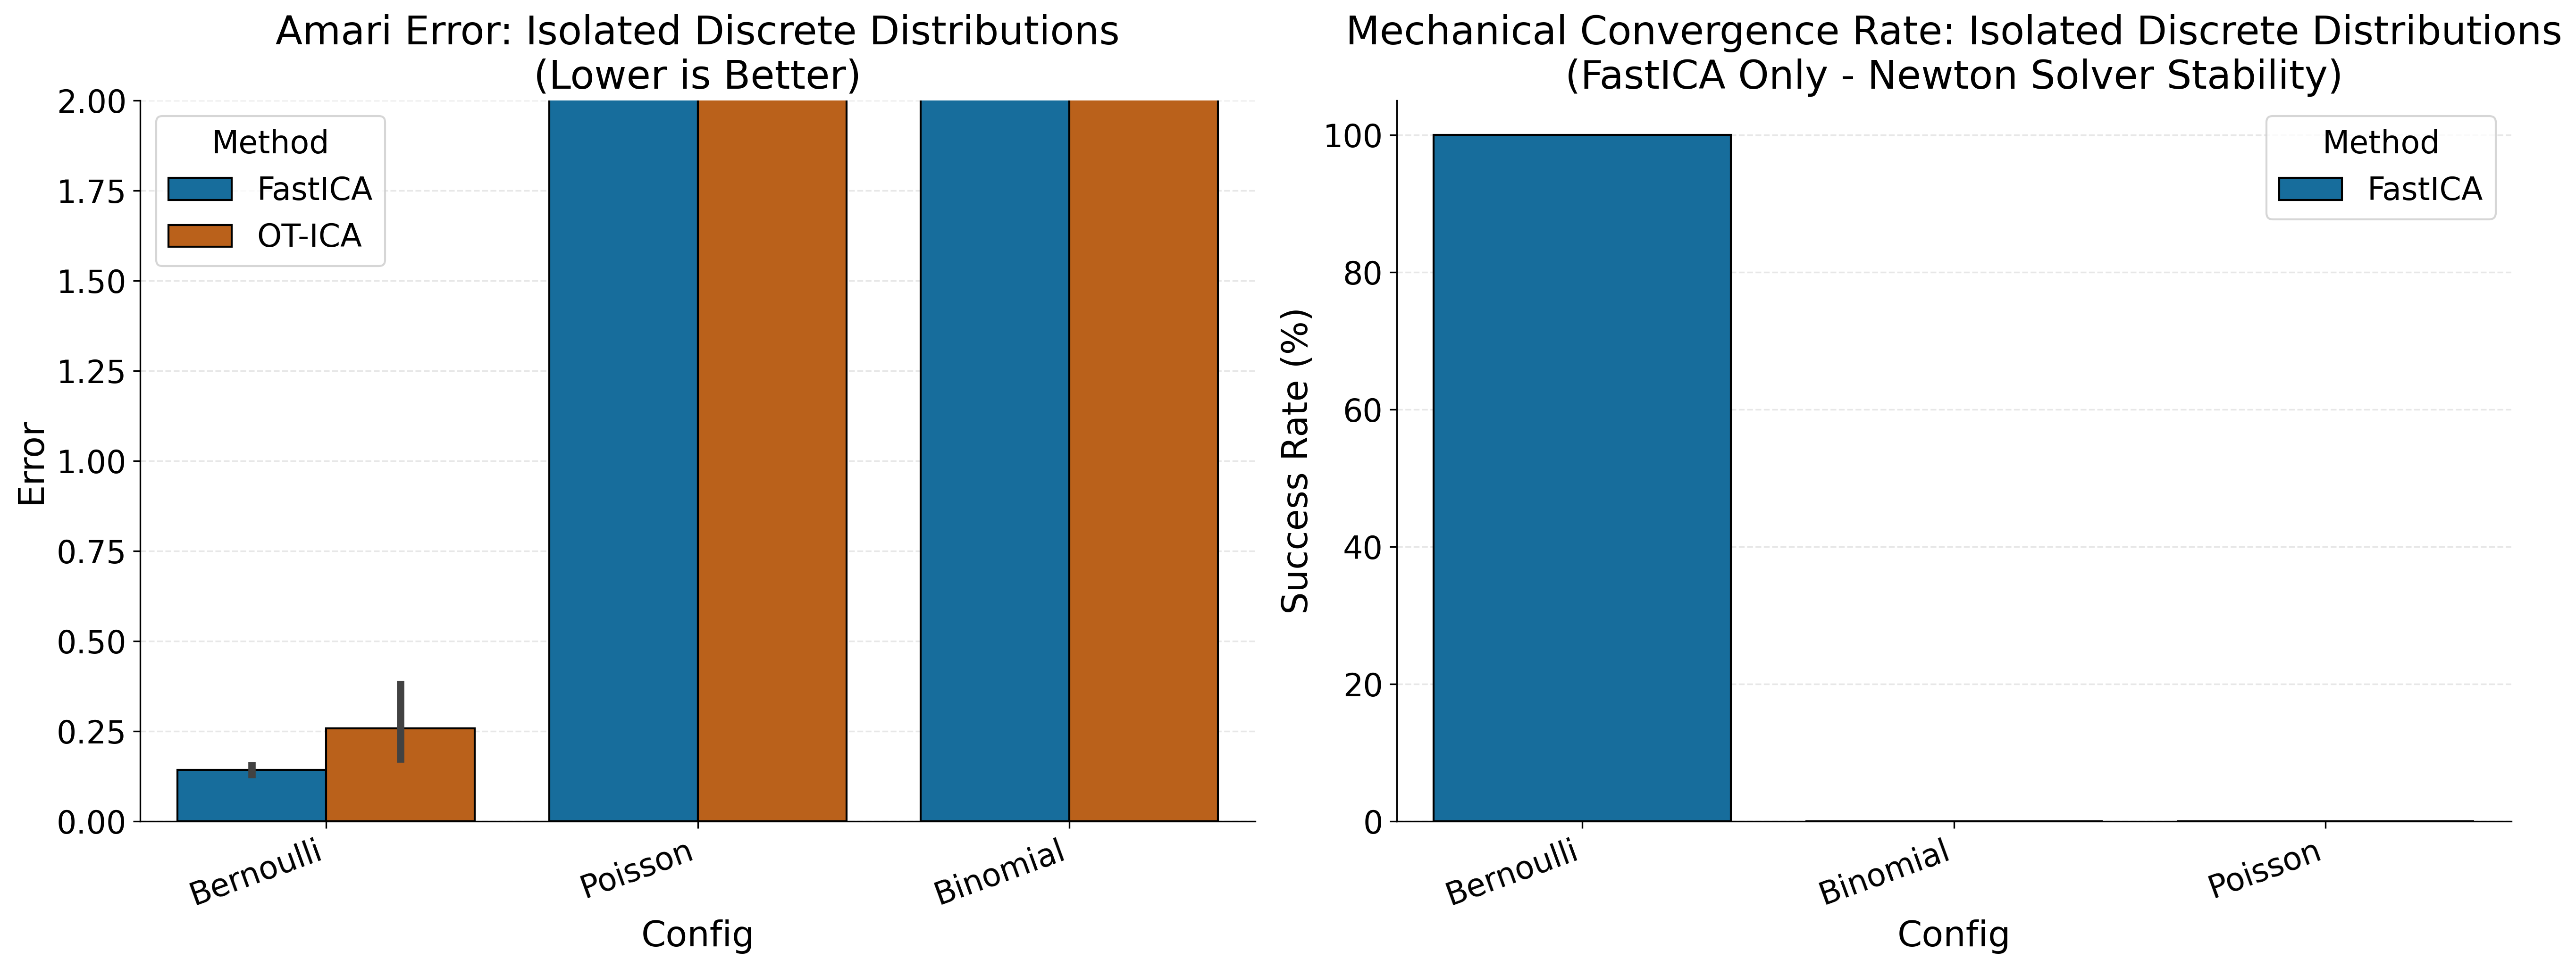

Error  Conv
Method  Config    Dim               
FastICA Bernoulli 30    0.1227   1.0
                  40    0.1620   1.0
        Binomial  30    8.4188   0.0
                  40   11.8596   0.0
        Poisson   30    8.0425   0.0
                  40   10.6933   0.0
OT-ICA  Bernoulli 30    0.1828   1.0
                  40    0.3330   1.0
        Binomial  30    9.4398   0.0
                  40   12.4772   0.0
        Poisson   30    3.8718   0.0
                  40    6.7625   0.0

In [8]:
DIST_TYPES = ['Bernoulli', 'Poisson', 'Binomial'] # Poisson is lam=3, Binomial is n=10

print("--- Step 2: Isolating Discrete Failure Modes ---")
tasks_disc = [(dim, trial, N_SAMPLES, d, m, None) for dim in DIMENSIONS for d in DIST_TYPES for m in METHODS for trial in range(N_TRIALS)]
results_discrete = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks_disc))

df_discrete = pd.DataFrame(results_discrete)
plot_results(df_discrete, "Isolated Discrete Distributions", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})

In [15]:
import numpy as np
import torch

def get_analytical_gaussian_target(n_samples):
    p = torch.linspace(0, 1, n_samples + 2)[1:-1]
    return torch.distributions.Normal(0, 1).icdf(p)

print("--- Step 3A: Non-Gaussianity Sensitivity Analysis (W2 Gap & Logcosh) ---")
n_samples = 10000
target = get_analytical_gaussian_target(n_samples)

# Pre-calculate FastICA baseline constant for logcosh
# (Using a large sample for a highly accurate baseline expectation)
v_large = np.random.normal(0, 1, 100000)
C_gauss = np.mean(np.log(np.cosh(v_large)))

dists = {
    'Poisson (Standard, λ=3.0)': np.random.poisson(3.0, n_samples),
    'Poisson (Harsh, λ=0.5)': np.random.poisson(0.5, n_samples),
    'Binomial (Standard, n=10)': np.random.binomial(10, 0.5, n_samples),
    'Binomial (Harsh, n=2)': np.random.binomial(2, 0.5, n_samples),
    'Laplace (Baseline)': np.random.laplace(0, 1, n_samples)
}

# Expanded table formatting to accommodate the new metric
print(f"{'Distribution':<30} | {'W2 Sq Distance':<15} | {'Logcosh Proxy Negentropy':<25}")
print("-" * 76)
for name, samples in dists.items():
    s = (samples - samples.mean()) / samples.std() # Standardize
    
    # 1. OT-ICA Metric: Squared Wasserstein-2
    sorted_s, _ = torch.sort(torch.tensor(s, dtype=torch.float32))
    w2_val = torch.mean((sorted_s - target)**2).item()
    
    # 2. FastICA Metric: Logcosh Proxy Negentropy
    logcosh_val = (np.mean(np.log(np.cosh(s))) - C_gauss)**2
    
    print(f"{name:<30} | {w2_val:<15.6f} | {logcosh_val:<25.6f}")

--- Step 3A: Non-Gaussianity Sensitivity Analysis (W2 Gap & Logcosh) ---
Distribution                   | W2 Sq Distance  | Logcosh Proxy Negentropy 
----------------------------------------------------------------------------
Poisson (Standard, λ=3.0)      | 0.051346        | 0.000000                 
Poisson (Harsh, λ=0.5)         | 0.338437        | 0.000085                 
Binomial (Standard, n=10)      | 0.034384        | 0.000031                 
Binomial (Harsh, n=2)          | 0.202233        | 0.000267                 
Laplace (Baseline)             | 0.039818        | 0.001214                 


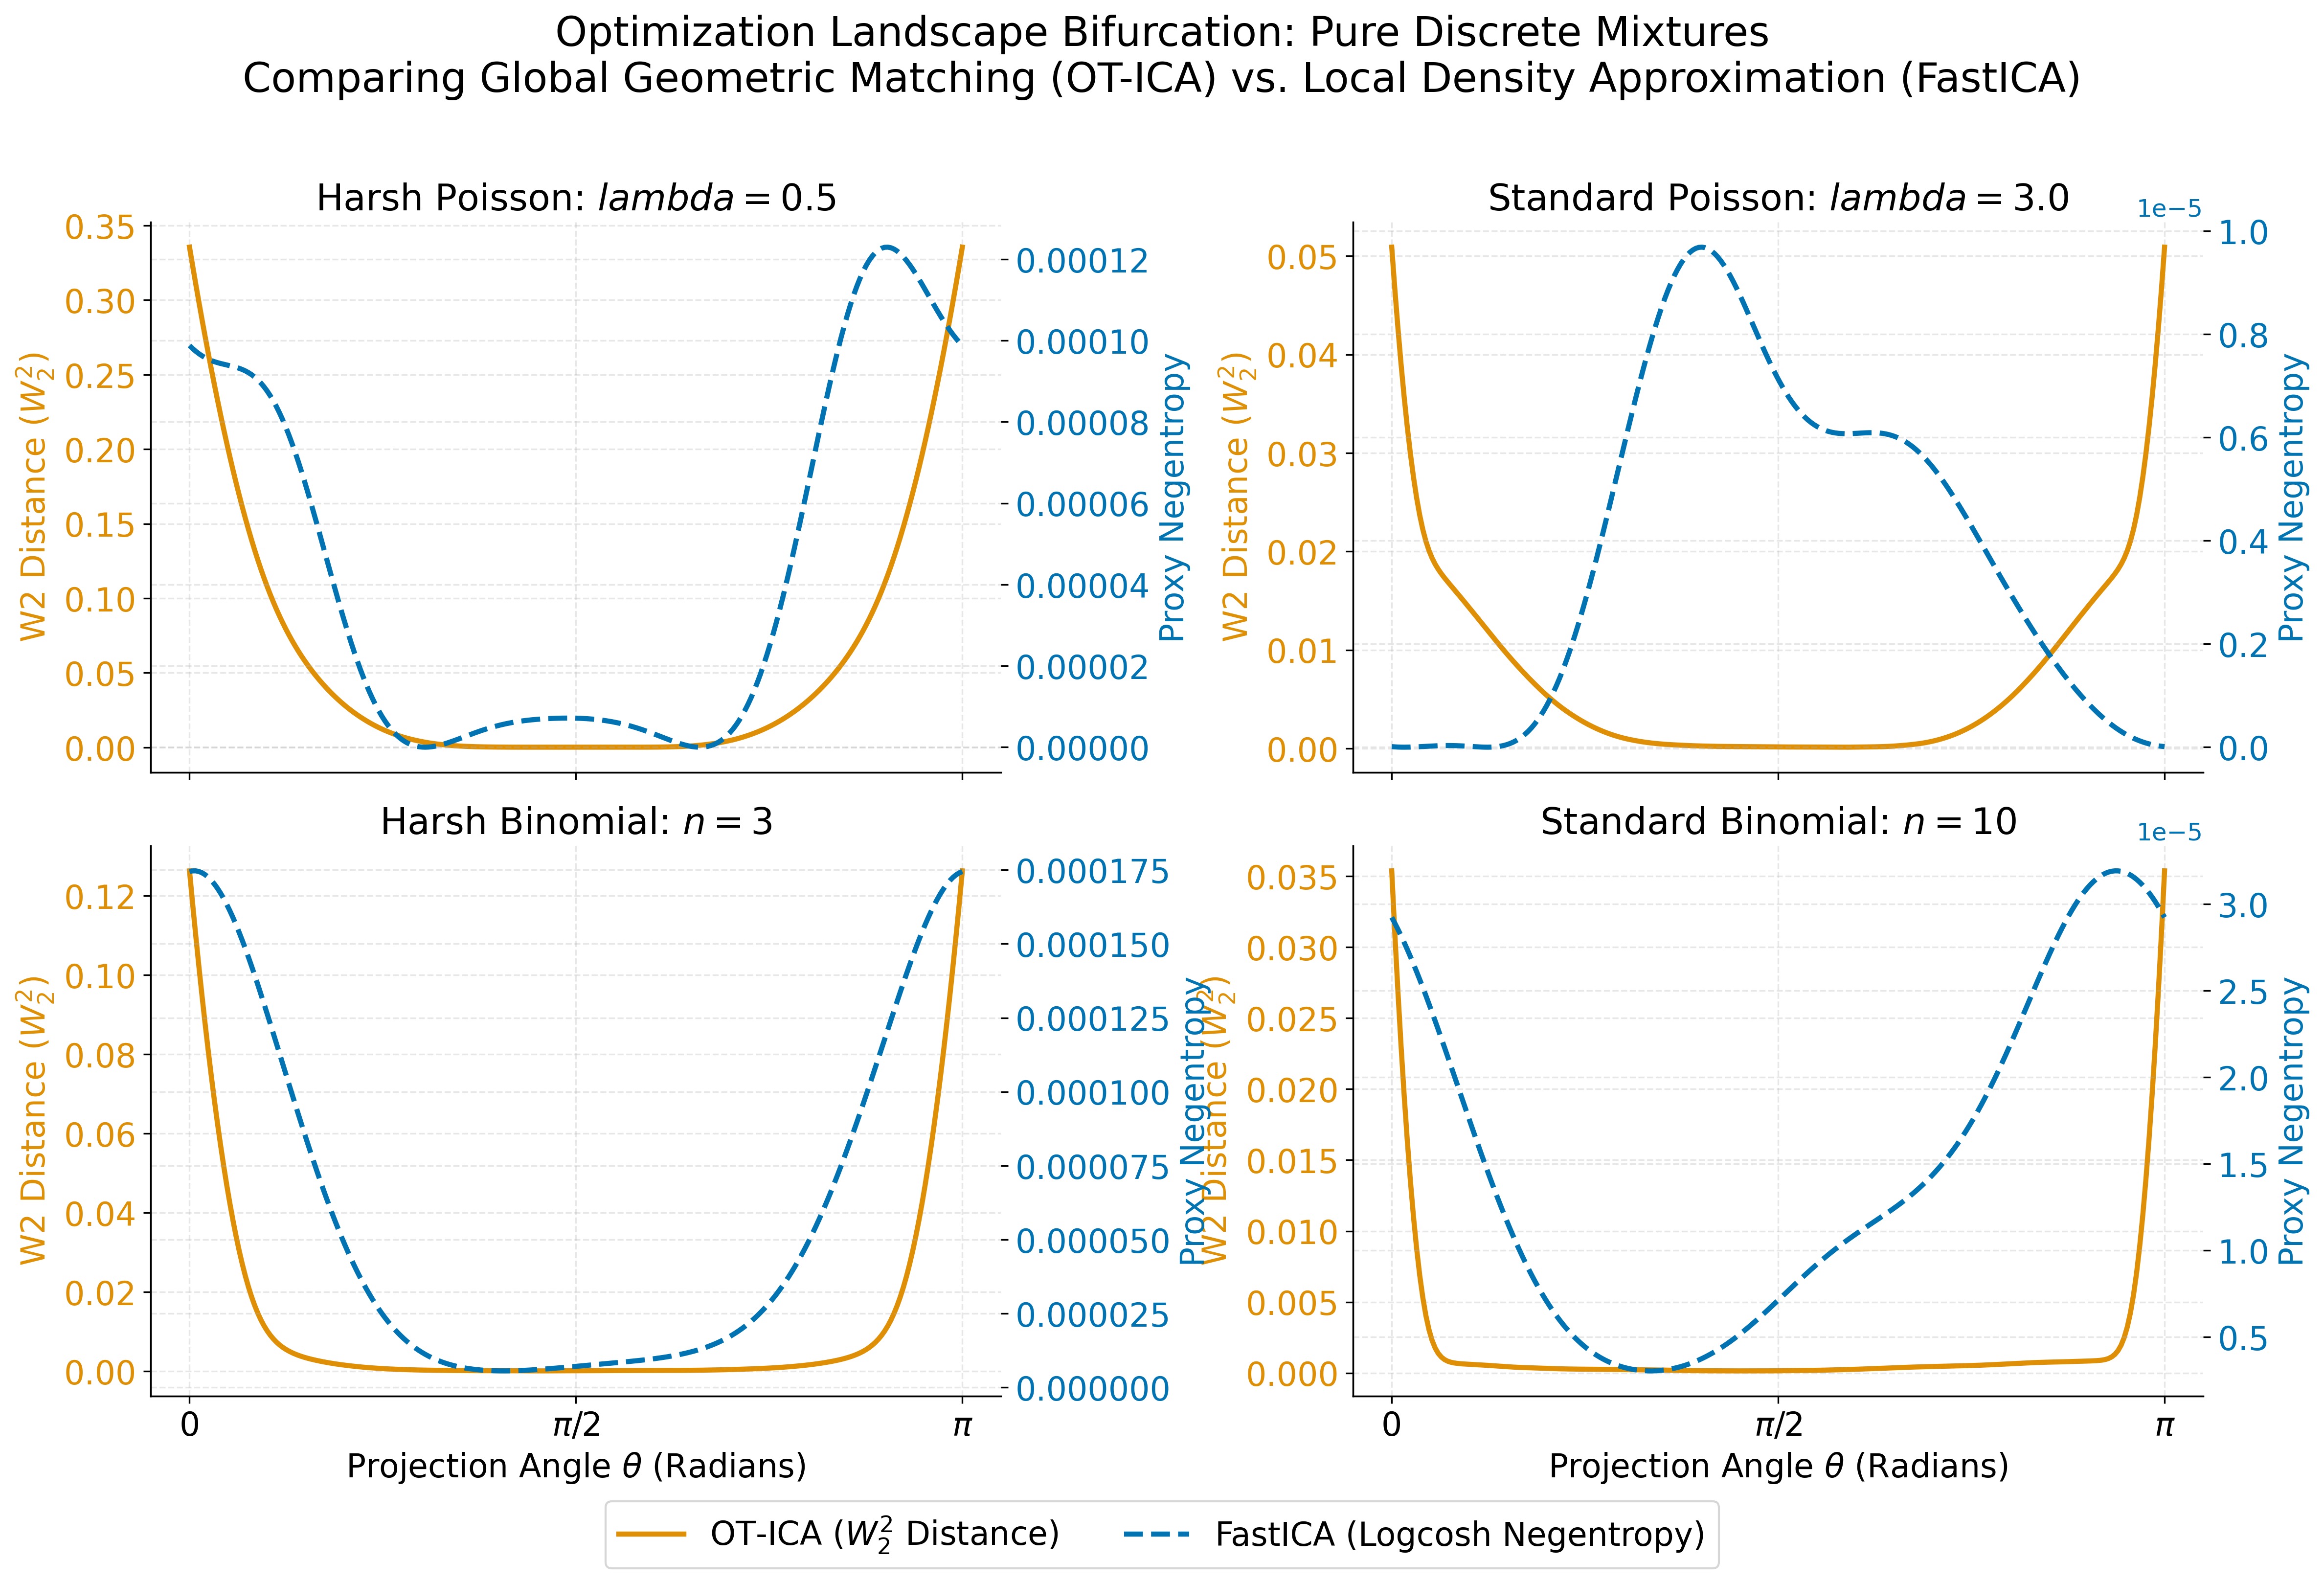

In [ ]:
# --- Font Size Controls ---
SUPTITLE_FS = 20  # Main figure title
TITLE_FS = 18     # Subplot titles
LABEL_FS = 16     # X/Y Axis labels
TICK_FS = 16      # X/Y Tick numbers and labels
LEGEND_FS = 16    # Legend text
# --------------------------------------

# Ensure get_analytical_gaussian_target is defined from Cell 1
def get_analytical_gaussian_target(n_samples, device='cpu'):
    p = torch.linspace(0, 1, n_samples + 2, device=device)[1:-1]
    return torch.distributions.Normal(0, 1).icdf(p)

# Encapsulate the twin-axis plotting logic into a reusable function
def plot_surface_on_ax(ax, title, dist_name, param_name, param_val, S, target, C_gauss):
    """
    Plots the twin-axis optimization surface for one mixed distribution.
    """
    
    thetas = np.linspace(0, np.pi, 250)
    w2_curve = []
    fastica_curve = []
    
    # Generate the objective function values for all angles
    for th in thetas:
        w = np.array([np.cos(th), np.sin(th)])
        y = w @ S
        y_std = (y - y.mean()) / y.std()
        
        # 1. OT-ICA Objective: Squared Wasserstein-2 Distance (Orange)
        y_torch = torch.sort(torch.tensor(y_std, dtype=torch.float32))[0]
        w2_curve.append(torch.mean((y_torch - target)**2).item())
        
        # 2. FastICA Objective: Proxy Negentropy via logcosh (Blue dashed)
        proxy_negentropy = (np.mean(np.log(np.cosh(y_std))) - C_gauss)**2
        fastica_curve.append(proxy_negentropy)
        
    # --- Twin Axis Plotting ---
    
    # Plot W2 Surface (OT-ICA)
    color_w2 = '#DE8F05' 
    ax.plot(thetas, w2_curve, color=color_w2, linewidth=2.5, label='OT-ICA ($W_2^2$)')
    ax.set_ylabel('W2 Distance ($W_2^2$)', color=color_w2, fontsize=LABEL_FS) # Updated size
    ax.tick_params(axis='y', labelcolor=color_w2, labelsize=TICK_FS)          # Updated size
    ax.tick_params(axis='x', labelsize=TICK_FS)                               # Updated size
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0', '$\\pi/2$', '$\\pi$'], fontsize=TICK_FS)         # Updated size
    
    # Dynamic title per plot
    ax.set_title(f"{title}: ${param_name} = {param_val}$", fontsize=TITLE_FS) # Updated size
    
    # Plot FastICA Logcosh Surface
    ax_fast = ax.twinx()
    color_fast = '#0173B2' 
    ax_fast.plot(thetas, fastica_curve, color=color_fast, linewidth=2.5, linestyle='--', label='FastICA (Logcosh)')
    ax_fast.set_ylabel('Proxy Negentropy', color=color_fast, fontsize=LABEL_FS) # Updated size
    ax_fast.tick_params(axis='y', labelcolor=color_fast, labelsize=TICK_FS)     # Updated size
    
    return ax_fast # Return to handle shared legend later

In [ ]:
# ==========================================
# Main execution to build the 2x2 grid
# ==========================================
n_samples = 10000
device = 'cpu' # Using CPU for local data logic

# 1. Pre-calculate static components to use across all plots
target_quantiles = get_analytical_gaussian_target(n_samples, device=device)

# Pre-calculate FastICA baseline constant
v_large = np.random.normal(0, 1, 100000)
C_gauss_static = np.mean(np.log(np.cosh(v_large)))

# Create the Gaussian source that will be mixed in every plot
s_gauss_src = np.random.normal(0, 1, n_samples)

# Define the grid of plot specifications
plots_spec = [
    {'title': 'Harsh Poisson', 'dist_name': 'Poisson', 'param_name': 'lambda', 'param_val': 0.5, 'pos': (0,0)},
    {'title': 'Standard Poisson', 'dist_name': 'Poisson', 'param_name': 'lambda', 'param_val': 3.0, 'pos': (0,1)},
    {'title': 'Harsh Binomial', 'dist_name': 'Binomial', 'param_name': 'n', 'param_val': 3, 'pos': (1,0)},
    {'title': 'Standard Binomial', 'dist_name': 'Binomial', 'param_name': 'n', 'param_val': 10, 'pos': (1,1)}
]

# Set up the figure with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Flatten axes array for easy iteration
axs_flat = axs.flatten()

# To preven multiple legends, store handle from last plot
final_handles = []

for i, spec in enumerate(plots_spec):
    # Determine the specific distribution type and standardize it
    ax = axs[spec['pos']]
    np.random.seed(i) # Set seed for dynamic data generation repeatability
    
    if spec['dist_name'] == 'Poisson':
        s_src = np.random.poisson(spec['param_val'], n_samples)
    else: # Binomial (using previous p=0.5 baseline)
        s_src = np.random.binomial(spec['param_val'], 0.5, n_samples)
        
    s_std_src = (s_src - np.mean(s_src)) / np.std(s_src)
    
    # Create the 2D data by mixing with Gaussian source
    S_mixed = np.vstack([s_std_src, s_gauss_src])
    
    # Generate the twin axes and plot
    ax_fast_returned = plot_surface_on_ax(ax, spec['title'], spec['dist_name'], spec['param_name'], spec['param_val'], S_mixed, target_quantiles, C_gauss_static)
    
    # Only collect handles from the last plot to create a single shared legend
    if i == len(plots_spec) - 1:
        lines_w2, labels_w2 = ax.get_legend_handles_labels()
        lines_fast, labels_fast = ax_fast_returned.get_legend_handles_labels()
        final_handles = lines_w2 + lines_fast

# Style the common layout properties
for i, ax in enumerate(axs.flatten()):
    if i >= 2: # Only set x-label for bottom row
        ax.set_xlabel('Projection Angle $\\theta$ (Radians)', fontsize=LABEL_FS) # Updated size

# Main figure-level styling
fig.suptitle("Optimization Landscape Bifurcation: Pure Discrete Mixtures\nComparing Global Geometric Matching (OT-ICA) vs. Local Density Approximation (FastICA)", fontsize=SUPTITLE_FS, y=1.02) # Updated size
fig.legend(final_handles, ['OT-ICA ($W_2^2$ Distance)', 'FastICA (Logcosh Negentropy)'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=LEGEND_FS, frameon=True) # Updated size
fig.tight_layout()

# Save final plot
#fig.savefig('all_optimization_surfaces.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("--- Step 4: Harsh Discrete Test (λ=0.5, n=3) ---")
# If it fails here, it proves the failure is due to geometric jaggedness, NOT a lack of non-Gaussianity!
HARSH_DIST = [('Poisson', 0.5), ('Binomial', 3)]

# Re-defining locally
DIMENSIONS = [30, 40]
N_SAMPLES = 10000
METHODS = ['FastICA', 'OT-ICA']
N_TRIALS = 5

tasks_harsh = [(dim, trial, N_SAMPLES, d, m, p) for dim in DIMENSIONS for (d, p) in HARSH_DIST for m in METHODS for trial in range(N_TRIALS)]
results_harsh = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks_harsh))

df_harsh = pd.DataFrame(results_harsh)

# If the background workers used the old function and dropped the key, 
# we manually reconstruct it from the original tasks list
if 'Config_Param' not in df_harsh.columns:
    df_harsh['Config_Param'] = [task[5] for task in tasks_harsh]

# Safe string formatting that won't crash if a value is missing
df_harsh['Config'] = df_harsh.apply(
    lambda row: f"{row['Config']} (param={row['Config_Param']})" if pd.notna(row.get('Config_Param')) else row['Config'], 
    axis=1
)

--- Step 4: Harsh Discrete Test (λ=0.5, n=3) ---


  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
def plot_results(df, title, palette, x_col='Config'):
    df_plot = df.copy()
    
    # --- NEW: Dynamic Mathematical Label Formatting ---
    def format_label(row):
        name = str(row[x_col])
        param_val = None
        
        # 1. Extract parameter if it was previously baked into the string (e.g. "Poisson (param=0.5)")
        if '(param=' in name:
            base = name.split(' (param=')[0]
            param_val = name.split('param=')[1].replace(')', '')
        # 2. Extract parameter if it was passed as a separate clean column
        elif 'Config_Param' in row and pd.notna(row['Config_Param']):
            base = name
            param_val = str(row['Config_Param'])
        else:
            return name # No parameters found, return as is
            
        # Apply distribution-specific notation
        if 'Poisson' in base:
            return f"{base} (λ={param_val})"
        elif 'Binomial' in base:
            try:
                # Convert floats like "3.0" into integer "3" for 'n'
                n_val = int(float(param_val))
                return f"{base} (n={n_val}, p=0.5)"
            except ValueError:
                return f"{base} (n={param_val}, p=0.5)"
        elif 'Bernoulli' in base:
            return f"{base} (p={param_val})"
        else:
            return f"{base} ({param_val})"
            
    # Apply clean labels to our working copy
    df_plot[x_col] = df_plot.apply(format_label, axis=1)
    # --------------------------------------------------

    # Display the numerical summary table first (so NaNs stay as NaNs in the text)
    display(df_plot.groupby(['Method', x_col, 'Dim'])[['Error', 'Conv']].mean().round(4))

    # Apply a visual penalty for strictly failed/NaN runs so they appear as tall bars on the chart
    df_plot['Error'] = df_plot['Error'].fillna(1.5) 

    # Prepare Convergence Data (FastICA ONLY)
    df_conv = df_plot[df_plot['Method'] == 'FastICA'].groupby(['Dim', x_col, 'Method'])['Conv'].mean().reset_index()
    df_conv['Success Rate (%)'] = df_conv['Conv'] * 100

    # --- Font Size Controls ---
    TITLE_FS = 20   # Title font size
    LABEL_FS = 18   # X/Y Axis label font size
    TICK_FS = 16    # X/Y Tick numbers/labels font size
    LEGEND_FS = 16  # Legend text and title font size
    # --------------------------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # --- Subplot 1: Amari Error (Both) ---
    sns.barplot(data=df_plot, x=x_col, y='Error', hue='Method', ax=ax1, palette=palette, edgecolor='black', errorbar='ci')
    
    # Apply sizes
    ax1.set_title(f"Amari Error: {title}\n(Lower is Better)", fontsize=TITLE_FS)
    ax1.set_xlabel(x_col, fontsize=LABEL_FS)
    ax1.set_ylabel('Error', fontsize=LABEL_FS)
    ax1.tick_params(axis='y', labelsize=TICK_FS)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
    ax1.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    
    ax1.set_ylim(0, 2.0) 

    # --- Subplot 2: Convergence Rate (FastICA Only) ---
    fast_palette = {'FastICA': palette['FastICA']}
    sns.barplot(data=df_conv, x=x_col, y='Success Rate (%)', hue='Method', ax=ax2, palette=fast_palette, edgecolor='black')
    
    # Apply sizes
    ax2.set_title(f"Mechanical Convergence Rate: {title}\n(FastICA Only - Newton Solver Stability)", fontsize=TITLE_FS)
    ax2.set_xlabel(x_col, fontsize=LABEL_FS)
    ax2.set_ylabel('Success Rate (%)', fontsize=LABEL_FS)
    ax2.tick_params(axis='y', labelsize=TICK_FS)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
    ax2.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    
    ax2.set_ylim(0, 105)

    plt.tight_layout()
    plt.show()

Error  Conv
Method  Config                Dim               
FastICA Binomial (n=3, p=0.5) 30    0.5008   1.0
                              40    0.6838   1.0
        Poisson (λ=0.5)       30    2.0678   0.0
                              40    3.9071   0.0
OT-ICA  Binomial (n=3, p=0.5) 30    7.6105   0.0
                              40   11.4859   0.0
        Poisson (λ=0.5)       30    0.1179   1.0
                              40    0.1550   1.0

/tmp/ipykernel_3352586/3038592748.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
/tmp/ipykernel_3352586/3038592748.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)


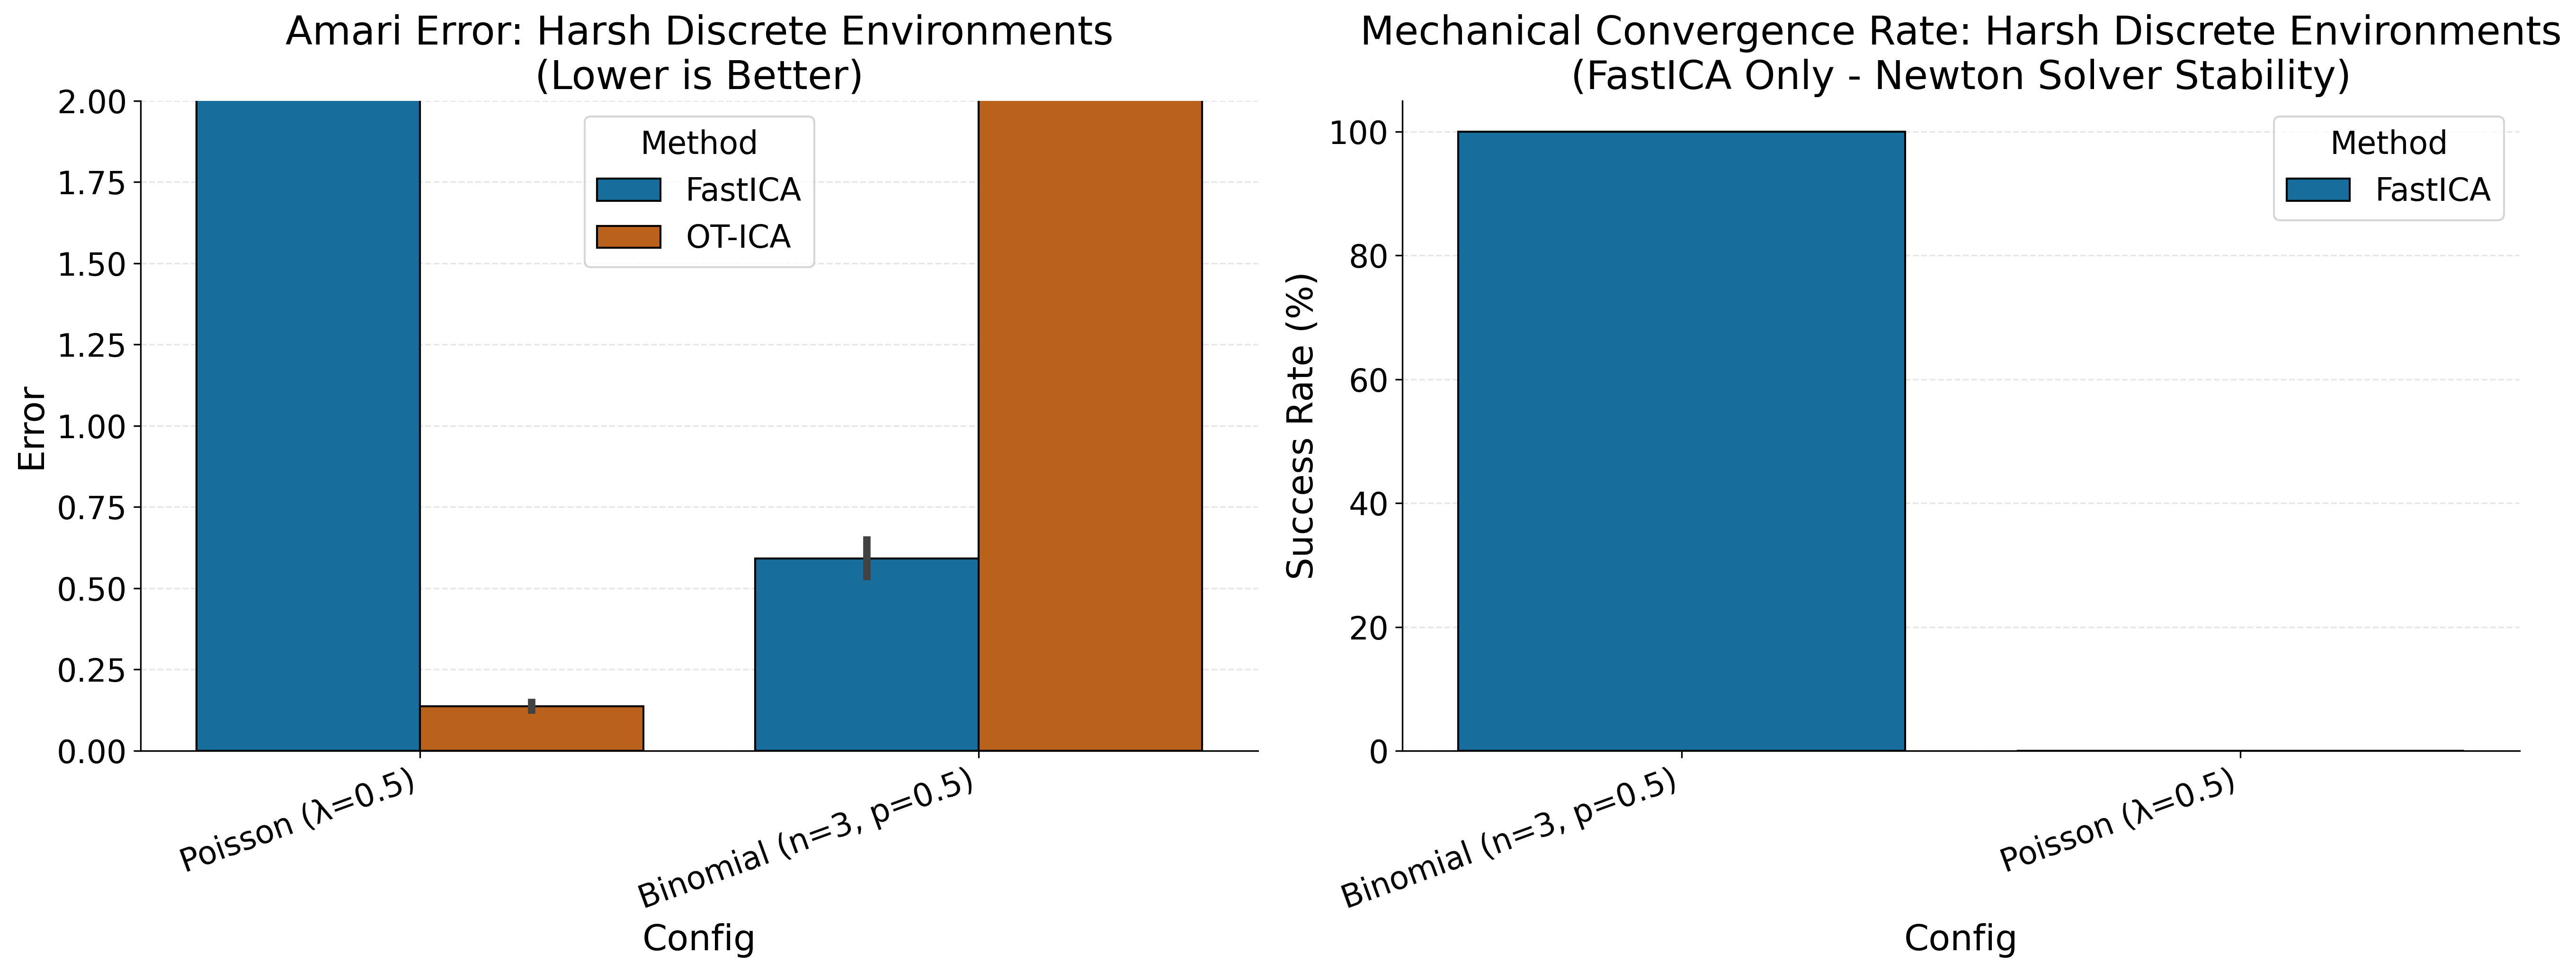

In [14]:
plot_results(df_harsh, "Harsh Discrete Environments", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})

In [21]:
def run_ica_regime_trial(dim, trial, n_samples, config_type, method, param, compute_level):
    torch.set_num_threads(1)
    X_np, A_true = generate_mixture(dim, n_samples, config_type, param, seed=trial)
    
    score = np.nan
    converged = False

    # Define hyperparams based on compute_level for OT-ICA
    if compute_level == 'Low Compute':
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 200
        w2_sym_iter = 400
    else:  # High Compute
        w2_restarts = min(dim * 15, 600)
        w2_def_iter = 300
        w2_sym_iter = 500

    if method == 'FastICA':
        # FastICA remains at "High Compute" (10k iterations) as requested
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            try:
                fast_ica = FastICA(n_components=dim, max_iter=10000, tol=1e-4, random_state=trial)
                fast_ica.fit(X_np.T)
                score = amari_error(fast_ica.components_, A_true)
                if not any(isinstance(m.message, ConvergenceWarning) for m in w):
                    if not np.isnan(score) and score < 1.0: converged = True
            except Exception: pass

    elif method == 'OT-ICA':
        try:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
            ica = WassersteinICA(X_torch)
            ica.whiten()
            W_white = ica.W_white.cpu().numpy()
            
            extracted = []
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, 
                    max_iter=w2_def_iter, 
                    n_restarts=w2_restarts, 
                    dither_sigma=0.01
                )
                extracted.append(w)
                
            W_stiefel = ica.optimize_symmetric(
                n_components=dim, 
                max_iter=w2_sym_iter, 
                lr=0.25, 
                init_w=torch.stack(extracted), 
                optimizer='stiefel', 
                dither_sigma=0.01, 
                batch_size=1024
            )
            score = amari_error(W_stiefel.cpu().numpy() @ W_white, A_true)
            if not np.isnan(score) and score < 1.0: converged = True
        except Exception: pass

    return {
        'Dim': dim, 
        'Config': config_type, 
        'Config_Param': param, 
        'Method': method, 
        'Compute': compute_level, # New column
        'Error': score, 
        'Conv': int(converged)
    }

In [22]:
print("--- Final Stress Test: Harsh Discrete vs. Compute Regimes ---")
HARSH_DIST = [('Poisson', 0.5), ('Binomial', 3)]
DIMENSIONS = [30, 40]
COMPUTE_REGIMES = ['Low Compute', 'High Compute']
METHODS = ['FastICA', 'OT-ICA']
N_TRIALS = 5

# Create the task list including the compute_level
tasks_regime = [
    (dim, trial, 10000, dist, method, param, regime) 
    for dim in DIMENSIONS 
    for (dist, param) in HARSH_DIST 
    for method in METHODS 
    for regime in COMPUTE_REGIMES 
    for trial in range(N_TRIALS)
]

results_regime = Parallel(n_jobs=8)(delayed(run_ica_regime_trial)(*t) for t in tqdm(tasks_regime))
df_regime = pd.DataFrame(results_regime)

--- Final Stress Test: Harsh Discrete vs. Compute Regimes ---


  0%|          | 0/80 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/tmp/ipykernel_3352586/3090304677.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)
/tmp/ipykernel_3352586/3090304677.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right", fontsize=TICK_FS)


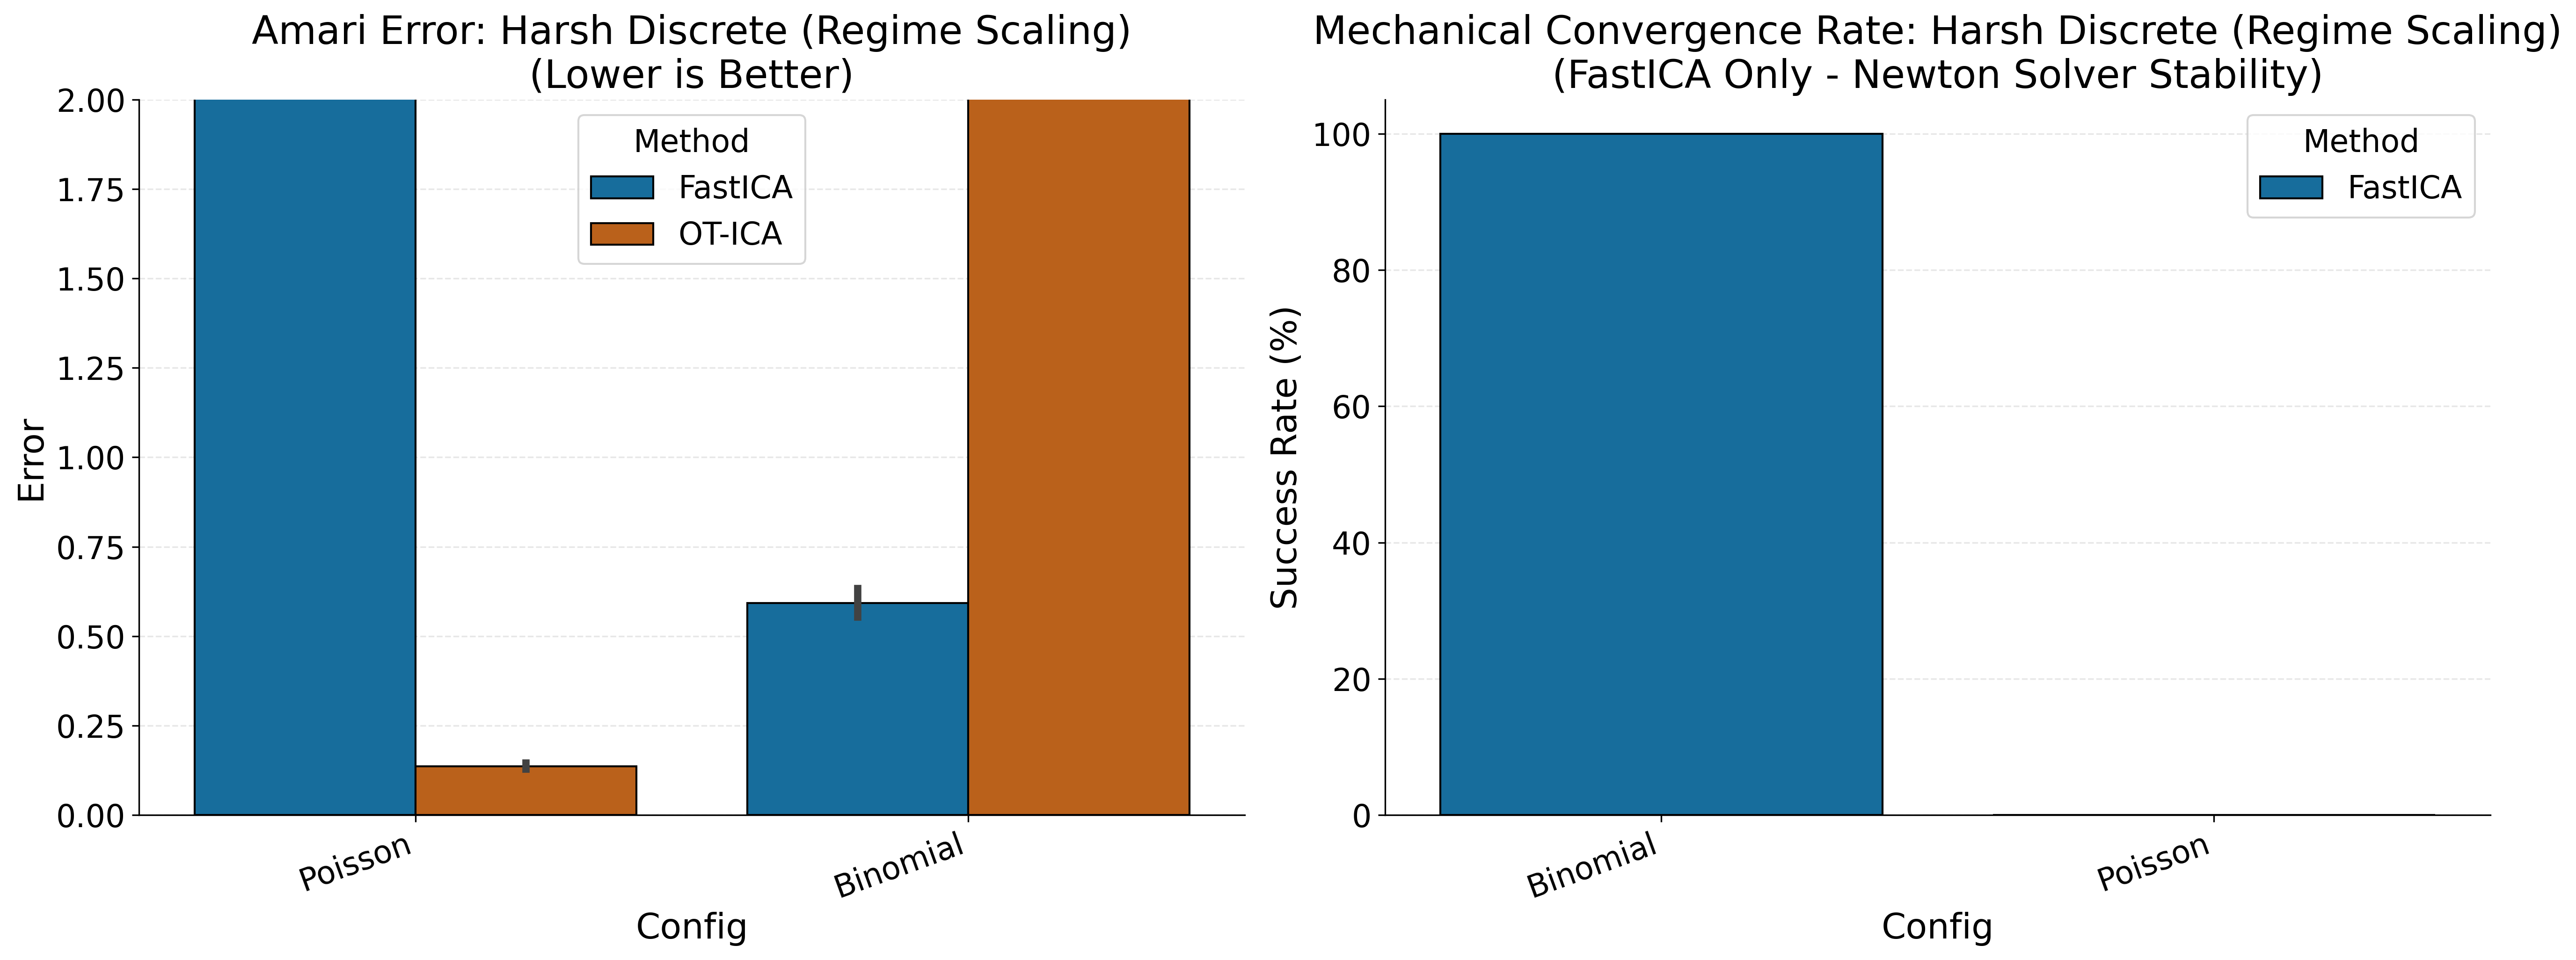

Error  Conv
Method  Config   Dim               
FastICA Binomial 30    0.5008   1.0
                 40    0.6838   1.0
        Poisson  30    2.0678   0.0
                 40    3.9071   0.0
OT-ICA  Binomial 30    7.6434   0.0
                 40   11.3017   0.0
        Poisson  30    0.1179   1.0
                 40    0.1549   1.0

In [23]:
# Updated plot call to use 'Compute' as the comparison facet
plot_results(df_regime, "Harsh Discrete (Regime Scaling)", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}, x_col='Config')